### Libraries

In [1]:
import json
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Set up Hugging Face cache directory
cache_dir = Path(r"C:/Users/User/Documents/devanasokan_fyp/huggingface_cache")
cache_dir.mkdir(parents=True, exist_ok=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", cache_dir=str(cache_dir))
print(f"Tokenizer vocab size: {len(tokenizer)}")

Tokenizer vocab size: 30522


### Setup

Choose between 2 different sets of data with different ratios

In [4]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/train70.csv")
val_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/val15.csv")
test_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/test15.csv")

In [5]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/train80.csv")
val_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/val10.csv")
test_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/test10.csv")

Once a set has been chosen, continue with next steps

In [6]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [7]:
print("train:", train_df.shape, train_df["label"].value_counts().sort_index().to_dict())
print("val:", val_df.shape, val_df["label"].value_counts().sort_index().to_dict())
print("test:", test_df.shape, test_df["label"].value_counts().sort_index().to_dict())

train: (18302, 2) {0: 9151, 1: 9151}
val: (2288, 2) {0: 1144, 1: 1144}
test: (2288, 2) {0: 1144, 1: 1144}


In [ ]:
# Determine the ratio based on the shape of the training DataFrame
if train_df.shape == (18302,2):
    ratio = "80:10:10"
else:
    ratio = "70:15:15"

In [8]:
MAX_LEN = 180


def tokenize(text: str) -> list[str]:
    return tokenizer.tokenize(text)


counter = Counter()
for text in train_df["verse"]:
    counter.update(tokenize(text))

vocab = tokenizer.get_vocab()

print(f"Vocabulary size: {len(vocab)}")
print("Most common tokens:", counter.most_common(10))

Token indices sequence length is longer than the specified maximum sequence length for this model (657 > 512). Running this sequence through the model will result in indexing errors


Vocabulary size: 30522
Most common tokens: [(',', 216322), ('i', 54906), ('you', 40629), ('the', 31056), ('to', 24273), ('it', 20227), ('a', 19852), ('me', 18337), ('and', 17799), ('not', 15771)]


In [9]:
def numericalize(text: str) -> tuple[torch.Tensor, torch.Tensor]:
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LEN,
    )
    if not token_ids:
        token_ids = [tokenizer.unk_token_id]
    length = len(token_ids)
    if len(token_ids) < MAX_LEN:
        token_ids += [tokenizer.pad_token_id] * (MAX_LEN - len(token_ids))
    return torch.tensor(token_ids, dtype=torch.long), torch.tensor(length, dtype=torch.long)

sample_ids, sample_length = numericalize(train_df.iloc[0]["verse"] )
print("sample length:", sample_length.item())
print("sample ids:", sample_ids[:20].tolist())

sample length: 61
sample ids: [2026, 1010, 2026, 1010, 2092, 1010, 2009, 2003, 25085, 2066, 2057, 2024, 2035, 2183, 2000, 3280, 1010, 2035, 2183, 2000]


In [10]:
class LyricsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["verse"].tolist()
        self.labels = frame["label"].astype(np.float32).tolist()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int):
        input_ids, length = numericalize(self.texts[index])
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return input_ids, length, label


batch_size = 64
train_loader = DataLoader(LyricsDataset(train_df), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(LyricsDataset(val_df), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(LyricsDataset(test_df), batch_size=batch_size, shuffle=False)

batch_input_ids, batch_lengths, batch_labels = next(iter(train_loader))
print(batch_input_ids.shape, batch_lengths.shape, batch_labels.shape)

torch.Size([64, 180]) torch.Size([64]) torch.Size([64])


### Model Training

In [11]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 256,
        hidden_dim: int = 256,
        num_layers: int = 3,
        bidirectional: bool = True,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh", # For RNN
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.rnn(packed)
        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        logits = self.fc(self.dropout(hidden))
        return logits.squeeze(1)


model = RNNClassifier(vocab_size=len(tokenizer)).to(device)
print(model)

RNNClassifier(
  (embedding): Embedding(30522, 256, padding_idx=0)
  (rnn): RNN(256, 256, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


In [12]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(loader: DataLoader, training: bool = True):
    model.train() if training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_targets = []

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Get probability scores
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.detach().cpu().tolist())

        predictions = (probs >= 0.5).long()
        all_predictions.extend(predictions.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().long().tolist())
        total_loss += loss.item() * input_ids.size(0)

    average_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    return average_loss, accuracy, all_targets, all_probs, all_predictions


with torch.no_grad():
    preview_logits = model(batch_input_ids.to(device), batch_lengths.to(device))
print("preview logits shape:", preview_logits.shape)

preview logits shape: torch.Size([64])


In [ ]:
num_epochs = 10
best_val_loss = float("inf")
best_model_path = Path("rnn_lyrics_classifier.pt")
history = []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, _, _, _ = run_epoch(train_loader, training=True)
    val_loss, val_acc, _, _, _ = run_epoch(val_loader, training=False)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=0.6862 train_acc=0.5674 | val_loss=0.6616 val_acc=0.5948
Epoch 02 | train_loss=0.6475 train_acc=0.6275 | val_loss=0.6464 val_acc=0.6206
Epoch 03 | train_loss=0.6156 train_acc=0.6595 | val_loss=0.6467 val_acc=0.6224
Epoch 04 | train_loss=0.6052 train_acc=0.6725 | val_loss=0.6311 val_acc=0.6700
Epoch 05 | train_loss=0.5651 train_acc=0.7113 | val_loss=0.6382 val_acc=0.6438


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.686190,0.567370,0.661609,0.594843
1,2,0.647457,0.627527,0.646361,0.620629
2,3,0.615628,0.659491,0.646657,0.622378
3,4,0.605191,0.672495,0.631073,0.670017
4,5,0.565129,0.711288,0.638223,0.643794


### Model Evaluation and Saving

After training, reload the best checkpoint and evaluate it once on the test split. Then save the model and vocabulary together for inference.

In [14]:
# Load the best model and evaluate on the test set
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc, test_targets, test_probs, test_predictions = run_epoch(test_loader, training=False)

#### Classification Report

In [22]:
report = classification_report(
    test_targets,
    test_predictions,
    output_dict=True
)

accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"RNN CLASSIFICATION REPORT (INITIAL - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

RNN CLASSIFICATION REPORT (INITIAL - 80:10:10):
Accuracy: 0.659527972027972
Precision: 0.6335040234089246
Recall: 0.756993006993007
F1-score: 0.6897650338510554


#### ROC-AUC Curve

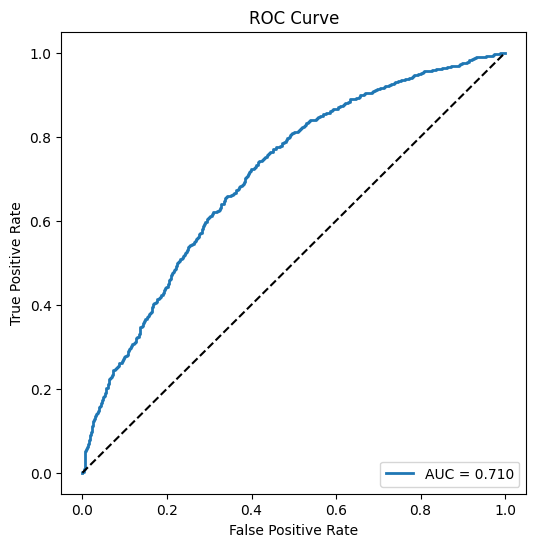

In [16]:
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.6856809566926736


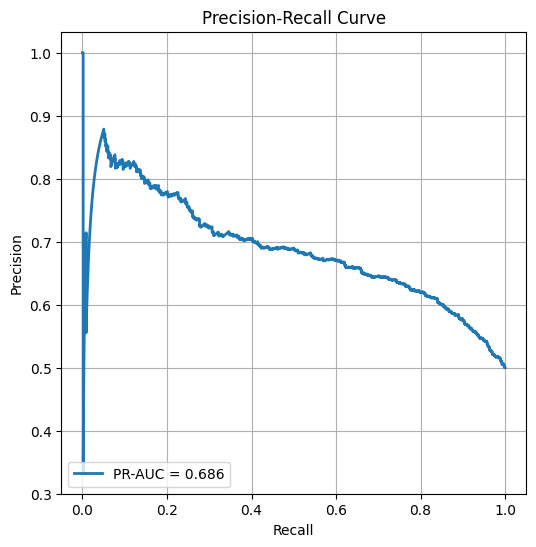

In [17]:
precision, recall, thresholds = precision_recall_curve(
    test_targets,
    test_probs
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

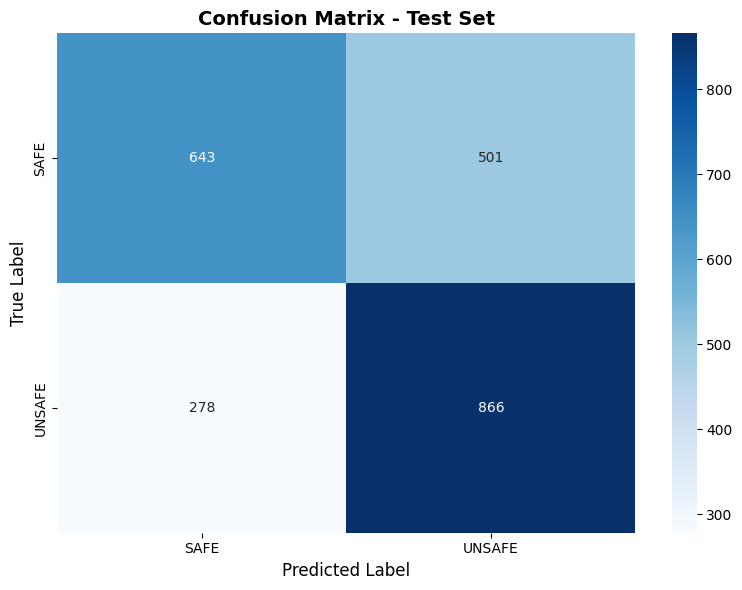

In [18]:
# Confusion matrix
cm = pd.crosstab(pd.Series(test_targets, name="Actual"), pd.Series(test_predictions, name="Predicted"))

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
artifact_dir = Path("rnn_artifacts")
artifact_dir.mkdir(exist_ok=True)

model_path = artifact_dir / "lyrics_rnn.pt"
vocab_path = artifact_dir / "lyrics_vocab.json"

torch.save(model.state_dict(), model_path)
with open(vocab_path, "w", encoding="utf-8") as vocab_file:
    json.dump(vocab, vocab_file, ensure_ascii=False, indent=2)

In [20]:
def predict_text(text: str):
    model.eval()
    input_ids, length = numericalize(text)
    with torch.no_grad():
        logits = model(input_ids.unsqueeze(0).to(device), length.unsqueeze(0).to(device))
        probability = torch.sigmoid(logits).item()
        prediction = int(probability >= 0.5)
    return probability, prediction


sample_probability, sample_prediction = predict_text(" you in the dark")
print({"probability": sample_probability, "prediction": sample_prediction})

{'probability': 0.15691033005714417, 'prediction': 0}
